<a href="https://colab.research.google.com/github/AbhienayaSri9509/NATIONAL-AIML-AVENA-YUVAN/blob/main/TrackA_AI_Manufacturing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 4000

data = pd.DataFrame({
    "Temperature": np.random.normal(180, 10, n),
    "Pressure": np.random.normal(5, 1, n),
    "Hold_Time": np.random.normal(60, 10, n),
    "Machine_RPM": np.random.normal(1500, 200, n),
    "Machine_Load": np.random.uniform(50, 100, n),
    "Batch_Size": np.random.randint(500, 2000, n)
})

# Targets
data["Energy_Consumption"] = (
    0.05 * data["Temperature"] +
    0.1 * data["Machine_Load"] +
    0.002 * data["Machine_RPM"] +
    np.random.normal(0, 2, n)
)

data["Quality_Score"] = (
    100 -
    0.03 * data["Temperature"] -
    0.05 * data["Machine_Load"] +
    np.random.normal(0, 1, n)
)

data["Yield_Percentage"] = (
    85 +
    0.01 * data["Temperature"] -
    0.02 * data["Machine_Load"] +
    np.random.normal(0, 1, n)
)

data["Performance_Index"] = (
    75 +
    0.02 * data["Machine_RPM"] / 100 -
    0.01 * data["Hold_Time"] +
    np.random.normal(0, 1, n)
)

data.head()

,Temperature,Pressure,Hold_Time,Machine_RPM,Machine_Load,Batch_Size,Energy_Consumption,Quality_Score,Yield_Percentage,Performance_Index
0,184.967142,4.136506,59.669747,1734.962812,75.919910,1767,20.739458,88.783889,86.714592,75.318381
1,178.617357,4.968797,54.963497,1124.203811,95.577452,1089,21.633583,89.609655,85.320603,76.107166
2,186.476885,5.018017,58.276250,1434.440989,66.297577,1122,17.995681,90.822431,85.599159,73.921261
3,195.230299,5.472630,67.147317,1491.667995,57.833607,1739,21.175520,92.294851,85.662297,74.214107
4,177.658466,3.633142,72.778567,1503.181732,85.436617,1464,21.966185,91.598776,84.995064,73.567485


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

X = data[["Temperature", "Pressure", "Hold_Time", "Machine_RPM", "Machine_Load", "Batch_Size"]]
y = data[["Energy_Consumption", "Quality_Score", "Yield_Percentage", "Performance_Index"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultiOutputRegressor(XGBRegressor())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.02898801863193512


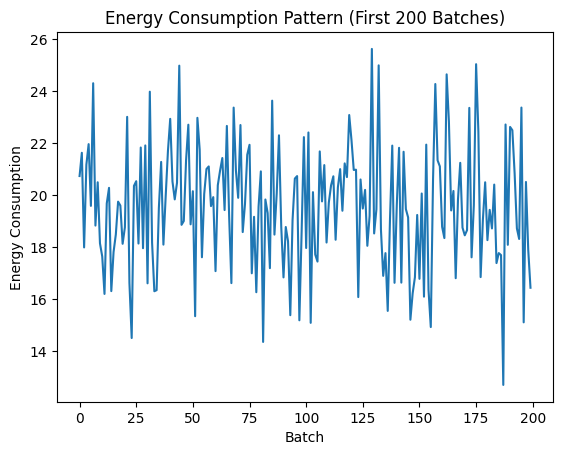

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(data["Energy_Consumption"].values[:200])
plt.title("Energy Consumption Pattern (First 200 Batches)")
plt.xlabel("Batch")
plt.ylabel("Energy Consumption")
plt.show()

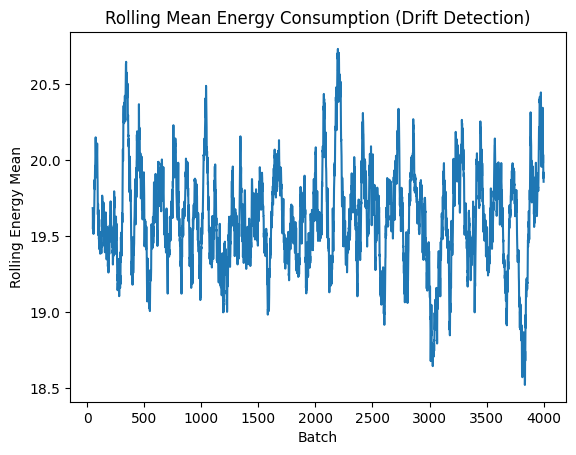

In [4]:
rolling_mean = data["Energy_Consumption"].rolling(window=50).mean()

plt.figure()
plt.plot(rolling_mean)
plt.title("Rolling Mean Energy Consumption (Drift Detection)")
plt.xlabel("Batch")
plt.ylabel("Rolling Energy Mean")
plt.show()

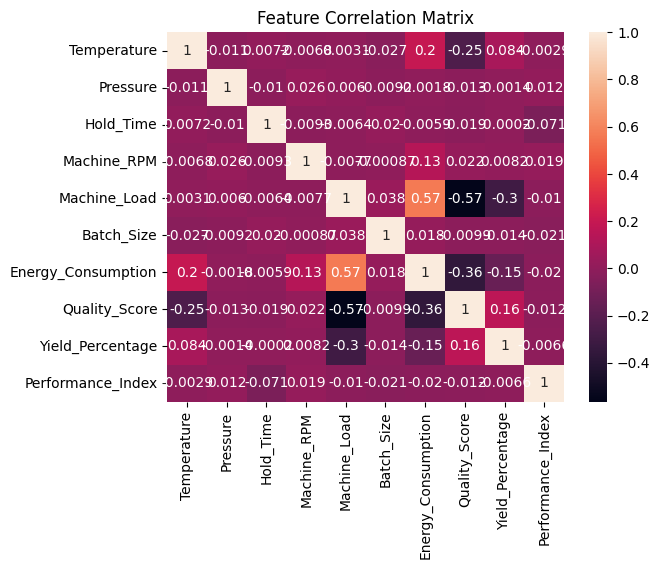

In [5]:
import seaborn as sns

plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [6]:
!pip install shap

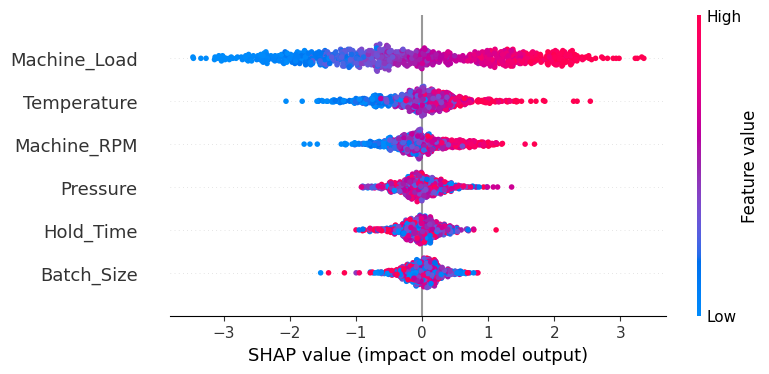

In [7]:
import shap

explainer = shap.Explainer(model.estimators_[0])
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [ ]:
### Energy Pattern Intelligence Insights

- High Machine Load increases energy consumption significantly.
- Temperature variations influence quality score.
- RPM variation affects performance index.
- Rolling energy drift can indicate maintenance need.

In [9]:
def predict_batch(temp, pressure, hold, rpm, load, batch_size):
    input_data = pd.DataFrame([[temp, pressure, hold, rpm, load, batch_size]],
                              columns=["Temperature", "Pressure", "Hold_Time",
                                       "Machine_RPM", "Machine_Load", "Batch_Size"])

    prediction = model.predict(input_data)

    return {
        "Predicted Energy": prediction[0][0],
        "Predicted Quality": prediction[0][1],
        "Predicted Yield": prediction[0][2],
        "Predicted Performance": prediction[0][3]
    }

In [10]:
predict_batch(185, 5.5, 60, 1600, 80, 1200)

{'Predicted Energy': np.float32(21.255175),
 'Predicted Quality': np.float32(90.296814),
 'Predicted Yield': np.float32(85.55664),
 'Predicted Performance': np.float32(74.48809)}

In [11]:
def carbon_logic(energy_value):
    carbon_factor = 0.82  # example kg CO2 per kWh
    carbon_emission = energy_value * carbon_factor

    if carbon_emission > 120:
        recommendation = "Reduce Machine Load or RPM to meet carbon target."
    else:
        recommendation = "Within carbon limits."

    return carbon_emission, recommendation

In [12]:
result = predict_batch(185, 5.5, 60, 1600, 80, 1200)
carbon_logic(result["Predicted Energy"])

(np.float32(17.429243), 'Within carbon limits.')

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

targets = ["Energy", "Quality", "Yield", "Performance"]

for i in range(4):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"\nTarget: {targets[i]}")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2:", round(r2, 3))


Target: Energy
MAE: 1.742
RMSE: 2.188
R2: 0.258

Target: Quality
MAE: 0.868
RMSE: 1.109
R2: 0.188

Target: Yield
MAE: 0.833
RMSE: 1.06
R2: -0.09

Target: Performance
MAE: 0.865
RMSE: 1.08
R2: -0.241


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

cv_model = MultiOutputRegressor(XGBRegressor())

scores = cross_val_score(cv_model, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", scores)
print("Average CV R2:", scores.mean())

Cross-validation R2 scores: [0.04898134 0.05368647 0.03687941 0.03052191 0.02267988]
Average CV R2: 0.03854980170726776


In [15]:
import joblib
joblib.dump(model, "multi_target_model.pkl")

['multi_target_model.pkl']

In [16]:
def intelligent_batch_analysis(temp, pressure, hold, rpm, load, batch_size):

    result = predict_batch(temp, pressure, hold, rpm, load, batch_size)
    carbon_emission, recommendation = carbon_logic(result["Predicted Energy"])

    print("\n--- Batch Analysis Report ---")
    print("Predicted Energy:", round(result["Predicted Energy"], 2))
    print("Predicted Quality:", round(result["Predicted Quality"], 2))
    print("Predicted Yield:", round(result["Predicted Yield"], 2))
    print("Predicted Performance:", round(result["Predicted Performance"], 2))
    print("Estimated Carbon Emission:", round(carbon_emission, 2))
    print("Recommendation:", recommendation)

In [17]:
intelligent_batch_analysis(185, 5.5, 60, 1600, 80, 1200)


--- Batch Analysis Report ---
Predicted Energy: 21.26
Predicted Quality: 90.3
Predicted Yield: 85.56
Predicted Performance: 74.49
Estimated Carbon Emission: 17.43
Recommendation: Within carbon limits.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_processed = pipeline.fit_transform(X)